<a href="https://colab.research.google.com/github/Kavishka2401/CustomerChurnPredictionSystem/blob/master/Final_NN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Mount the google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Core libraries
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Scikit-learn libraries
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    f1_score,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report
)

# Imbalanced-learn library
from imblearn.over_sampling import BorderlineSMOTE

# TensorFlow / Keras libraries
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import AUC, Precision, Recall
from tensorflow.keras.regularizers import l2

# Reproducibility / Seed setup
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'


In [5]:
# Provide path
df = pd.read_csv('/content/drive/MyDrive/processed_data_NN.csv')
# Copy data
churn_data = df.copy()

In [6]:
churn_data.columns

Index(['TotalCharges_numeric', 'tenure', 'MonthlyCharges', 'SeniorCitizen',
       'AvgChargePerMonth', 'Churn', 'Dependents_Yes',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes'],
      dtype='object')

In [7]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows if needed
pd.set_option('display.max_rows', None)

# Prevent truncation of long strings in cells
pd.set_option('display.max_colwidth', None)

churn_data.head()

,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Churn,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,0.072892,0.013889,0.115423,0,0.090838,0,0,0,0,0,1,0,0,0,0,0,0,1
1,0.749358,0.472222,0.385075,0,0.342582,0,0,0,1,0,0,0,1,0,0,1,0,0
2,0.280590,0.027778,0.354229,0,0.262376,1,0,0,1,0,1,0,0,0,0,0,0,1
3,0.745063,0.625000,0.239303,0,0.283037,0,0,0,1,0,0,0,1,0,1,1,0,0
4,0.335724,0.027778,0.521891,0,0.329474,1,0,0,0,0,0,0,0,0,0,0,0,1


In [8]:
# INITIATE X AND Y
X = churn_data.drop(columns=['Churn'])
y = churn_data['Churn']

# Randomly select 10 samples for inference
X_infer = X.sample(n=10, random_state=42)
y_infer = y.loc[X_infer.index]

# Remove inference rows from main dataset
X_rest = X.drop(X_infer.index)
y_rest = y.drop(y_infer.index)

# First, split off the test set (15% of total data)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_rest, y_rest,
    test_size=0.15,       # 15% test set
    random_state=42,
    stratify=y_rest
)

# Then, split the remaining 85% into training (70%) and validation (15%)
# To get correct proportion, validation size = 15 / 85 ≈ 0.176
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,      # ~15% of total data
    random_state=SEED,
    stratify=y_train_val
)

# Check shapes
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("X_infer:", X_infer.shape)

# Check class distribution in original training set
print("Original training set class distribution:")
print(y_train.value_counts())

# Percentages
print("\nOriginal training set class distribution (percentages):")
print(y_train.value_counts(normalize=True) * 100)

X_train: (4925, 17)
X_val: (1053, 17)
X_test: (1055, 17)
X_infer: (10, 17)
Original training set class distribution:
Churn
0    3620
1    1305
Name: count, dtype: int64

Original training set class distribution (percentages):
Churn
0    73.502538
1    26.497462
Name: proportion, dtype: float64


After Borderline-SMOTE class counts:
 Churn
1    3620
0    3620
Name: count, dtype: int64
Class weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


227/227 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6343 - f1_metric: 0.5921 - loss: 0.7373 - val_accuracy: 0.6942 - val_f1_metric: 0.5636 - val_loss: 0.6333 - learning_rate: 5.0000e-04
Epoch 2/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7063 - f1_metric: 0.7217 - loss: 0.6475 - val_accuracy: 0.6714 - val_f1_metric: 0.5474 - val_loss: 0.6169 - learning_rate: 5.0000e-04
Epoch 3/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7247 - f1_metric: 0.7456 - loss: 0.6153 - val_accuracy: 0.6705 - val_f1_metric: 0.5486 - val_loss: 0.6095 - learning_rate: 5.0000e-04
Epoch 4/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7371 - f1_metric: 0.7593 - loss: 0.5971 - val_accuracy: 0.6762 - val_f1_metric: 0.5567 - val_loss: 0.5981 - learning_rate: 5.0000e-04
Epoch 5/100
227/227 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7235 - f1_metric: 0.7470 - loss: 0.5912 - val_accuracy: 0.6714 - val_f1_metric: 0.5573 - val_loss: 0.5984 - learning_rate: 5.0000e-04
Epoch 

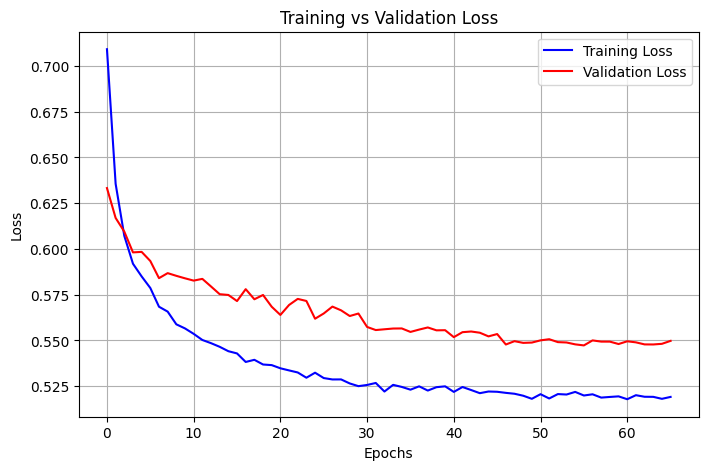

In [35]:
# Apply Borderline-SMOTE on training set only
smote = BorderlineSMOTE(
    sampling_strategy='auto',
    random_state=42,
    kind='borderline-2'
)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print("After Borderline-SMOTE class counts:\n", pd.Series(y_train_res).value_counts())

# Compute class weights on resampled training data
classes = np.unique(y_train_res)
class_weights_values = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_res)
class_weight_dict = dict(zip(classes, class_weights_values))
print("Class weights:", class_weight_dict)

# Initialize simplified model
model = Sequential()

# Input layer + first hidden layer
model.add(tf.keras.layers.Dense(
    units=32,
    activation='relu',
    input_shape=(X_train_res.shape[1],),
    kernel_regularizer=l2(0.002)
))
model.add(tf.keras.layers.Dropout(0.2, seed=SEED))

# Second hidden layer
model.add(tf.keras.layers.Dense(
    units=16,
    activation='relu',
    kernel_regularizer=l2(0.002)
))
model.add(tf.keras.layers.Dropout(0.2, seed=SEED))

# Output layer
model.add(Dense(units=1, activation='sigmoid'))

# Custom F1 metric
def f1_metric(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.round(y_pred)
    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))
    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())
    return 2 * (precision * recall) / (precision + recall + tf.keras.backend.epsilon())

opt = Adam(learning_rate=0.0005)
# Compile model
model.compile(
    optimizer=opt,
    loss='binary_crossentropy',
    metrics=['accuracy', f1_metric]
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

# Train model with class weights
history = model.fit(
    X_train_res, y_train_res,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

# Predict and find best threshold
y_probs = model.predict(X_test).ravel()
thresholds = np.arange(0.1, 0.9, 0.05)
best_t = 0.5
best_f1 = 0

for t in thresholds:
    preds = (y_probs > t).astype(int)
    f1 = f1_score(y_test, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_t = t
print("Best Threshold:", best_t)

# Predictions
y_train_pred = (model.predict(X_train_res) > best_t).astype(int)
y_val_pred = (model.predict(X_val) > best_t).astype(int)
y_test_pred = (model.predict(X_test) > best_t).astype(int)

# Evaluate
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred)
rec = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)

# Classification reports
print("Training Set Report")
print(classification_report(y_train_res, y_train_pred))
print("Validation Set Report")
print(classification_report(y_val, y_val_pred))
print("Test Set Report")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:\n", cm)

# Plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], 'b-', label='Training Loss')
plt.plot(history.history['val_loss'], 'r-', label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [39]:
# Save the entire model
# Define path in your Google Drive
model_path = '/content/drive/MyDrive/NN_model.h5'

# Save the model
model.save(model_path)
print("Model saved to Google Drive at:", model_path)

# Save history
import pickle
with open('/content/drive/MyDrive/NN_model_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Save
with open('/content/drive/MyDrive/X_train_res.pkl', 'wb') as f:
    pickle.dump(X_train_res, f)
with open('/content/drive/MyDrive/y_train_res.pkl', 'wb') as f:
    pickle.dump(y_train_res, f)

Model saved to Google Drive at: /content/drive/MyDrive/NN_model.h5


In [3]:
from tensorflow.keras.models import load_model
model_path = '/content/drive/MyDrive/NN_model.h5'

# Load model
model = load_model(model_path, compile=False)

# Load History
with open('/content/drive/MyDrive/history.pkl', 'rb') as f:
    history = pickle.load(f)

# Load later
with open('/content/drive/MyDrive/X_train_res.pkl', 'rb') as f:
    X_train_res = pickle.load(f)
with open('/content/drive/MyDrive/y_train_res.pkl', 'rb') as f:
    y_train_res = pickle.load(f)

In [40]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 32)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,365 (13.15 KB)

 Trainable params: 1,121 (4.38 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,244 (8.77 KB)

In [41]:
# Reset indices for proper alignment
X_infer_reset = X_infer.reset_index(drop=True)
y_infer_reset = y_infer.reset_index(drop=True)

# Predict probabilities and apply best threshold
y_infer_probs = model.predict(X_infer_reset).ravel()
y_infer_pred = (y_infer_probs > 0.1).astype(int)

# Convert actual labels to numeric 0/1 if needed
y_infer_numeric = y_infer_reset.replace({'Non-Churn':0,'Churn':1})

# Map numeric labels to strings for display
label_map = {0:'Non-Churn', 1:'Churn'}
actual_labels = y_infer_numeric.map(label_map)
pred_labels = pd.Series(y_infer_pred).map(label_map)

# Build inference table
inference_table = X_infer_reset.copy()
inference_table['Actual'] = actual_labels
inference_table['Predicted'] = pred_labels
inference_table['Correct?'] = inference_table['Actual'] == inference_table['Predicted']

# Reorder columns
cols = ['Actual','Predicted','Correct?'] + [c for c in inference_table.columns if c not in ['Actual','Predicted','Correct?']]
inference_table = inference_table[cols]

# Display table
display(inference_table)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


,Actual,Predicted,Correct?,TotalCharges_numeric,tenure,MonthlyCharges,SeniorCitizen,AvgChargePerMonth,Dependents_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes
0,Churn,Churn,True,0.043508,0.013889,0.065174,0,0.055766,0,0,0,0,0,0,0,0,0,0,0,1
1,Non-Churn,Churn,False,0.644259,0.569444,0.069652,0,0.180210,0,1,0,1,0,1,0,1,0,0,0,1
2,Non-Churn,Non-Churn,True,0.649968,0.722222,0.010945,0,0.141804,1,1,0,1,0,1,0,1,0,0,1,0
3,Churn,Churn,True,0.223983,0.013889,0.578109,0,0.273706,0,0,0,0,0,0,1,0,0,0,0,0
4,Non-Churn,Non-Churn,True,0.838977,0.930556,0.321393,0,0.318930,0,0,0,0,0,0,0,0,1,0,1,0
5,Churn,Churn,True,0.942680,0.944444,0.709950,1,0.442244,0,0,0,0,1,0,0,0,0,0,0,1
6,Non-Churn,Non-Churn,True,0.737638,0.319444,0.586070,0,0.403762,1,0,1,0,0,0,1,0,1,0,1,1
7,Non-Churn,Non-Churn,True,0.909805,1.000000,0.535821,0,0.390817,1,0,1,0,1,0,1,0,1,0,1,0
8,Churn,Churn,True,0.970326,0.972222,0.853234,0,0.470319,0,0,1,0,0,0,0,0,1,0,1,1
9,Churn,Churn,True,0.004907,0.013889,0.011443,0,0.010054,0,1,0,1,0,1,0,1,0,0,0,0


Final Advanced Model – Summary

Test Metrics

    Accuracy: 0.7706

    Precision: 0.5525

    Recall: 0.7143

    F1 Score: 0.6231

Training Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.69      | 0.79   | 0.74     | 3620    |
| 1                | 0.76      | 0.65   | 0.70     | 3620    |
| **Accuracy**     |           |        | 0.72     | 7240    |
| **Macro Avg**    | 0.72      | 0.72   | 0.72     | 7240    |
| **Weighted Avg** | 0.72      | 0.72   | 0.72     | 7240    |




Validation Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.87      | 0.79   | 0.83     | 774     |
| 1                | 0.54      | 0.68   | 0.60     | 279     |
| **Accuracy**     |           |        | 0.76     | 1053    |
| **Macro Avg**    | 0.70      | 0.73   | 0.71     | 1053    |
| **Weighted Avg** | 0.78      | 0.76   | 0.77     | 1053    |



Test Set Report
| Class            | Precision | Recall | F1-Score | Support |
| ---------------- | --------- | ------ | -------- | ------- |
| 0                | 0.88      | 0.79   | 0.84     | 775     |
| 1                | 0.55      | 0.71   | 0.62     | 280     |
| **Accuracy**     |           |        | 0.77     | 1055    |
| **Macro Avg**    | 0.72      | 0.75   | 0.73     | 1055    |
| **Weighted Avg** | 0.80      | 0.77   | 0.78     | 1055    |




|              | Pred 0 | Pred 1 |
| ------------ | ------ | ------ |
| **Actual 0** | 613    | 162    |
| **Actual 1** | 80     | 200    |